# Anayzing Data

## Import Packages

In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Read Data

In [2]:
df_train = pd.read_csv('mental-health-data/train.csv')
df_test  = pd.read_csv('mental-health-data/test.csv')

In [3]:
print(df_train.shape)
df_train.head()

(140700, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [4]:
# print data types
df_train.dtypes

id                                         int64
Name                                      object
Gender                                    object
Age                                      float64
City                                      object
Working Professional or Student           object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

In [5]:
# check missing values
print(df_train.isnull().sum())

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64


In [6]:
# split columns by type
label_column = 'Depression'
num_columns  = df_train.select_dtypes(include=['int64', 'float64']).columns.drop(label_column)
obj_columns  = df_train.select_dtypes(include=['object']).columns

print(f"Label: {label_column}")
print(f"Numerical columns: {num_columns}")
print(f"Categorical columns: {obj_columns}")

Label: Depression
Numerical columns: Index(['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress'],
      dtype='object')
Categorical columns: Index(['Name', 'Gender', 'City', 'Working Professional or Student',
       'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')


In [7]:
# Find unique values in categorical columns
for col in obj_columns:
    num_unique = df_train[col].nunique()
    print(f"Column '{col}' has {num_unique} unique values")

Column 'Name' has 422 unique values
Column 'Gender' has 2 unique values
Column 'City' has 98 unique values
Column 'Working Professional or Student' has 2 unique values
Column 'Profession' has 64 unique values
Column 'Sleep Duration' has 36 unique values
Column 'Dietary Habits' has 23 unique values
Column 'Degree' has 115 unique values
Column 'Have you ever had suicidal thoughts ?' has 2 unique values
Column 'Family History of Mental Illness' has 2 unique values


## Plotting Diagram

### Functions

In [118]:
def create_plot(num_columns, **kwargs):
    row = (num_columns + 3) // 4
    col = min(num_columns, 4)
    width = min(num_columns * 4, 16)
    height = row * 3.5

    fig, axes = plt.subplots(row, col, figsize=(width, height), **kwargs)
    if num_columns > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    return fig, axes

In [48]:
def draw_histogram(data, columns, bins=[]):
    fig, axs = create_plot(len(columns), sharey=True)
    for i, column in enumerate(columns):
        bin = 10 if not bins else bins[i]
        axs[i].hist(data[column], edgecolor='black', bins=bin)
        axs[i].set_xlabel(column)

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(pad=1.5)
    plt.show()

In [49]:
def draw_pie_chart(data, columns):
    fig, axs = create_plot(len(columns))
    for i, column in enumerate(columns):
        counts = data[column].value_counts()
        axs[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
        axs[i].set_title(column)

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [50]:
def draw_box_plot(data, columns, target=None):
    fig, axs = create_plot(len(columns))
    for i, column in enumerate(columns):
        if target:
            data.boxplot(column=column, by=target, ax=axs[i])
            axs[i].set_title(f'{column} by {target}')
            axs[i].figure.suptitle('')
        else:
            data.boxplot(column=column, ax=axs[i])
            axs[i].set_title(f'{column}')
        axs[i].set_ylabel(column)

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

In [123]:
def draw_stack_bar(data, columns, target):
    fig, axs = create_plot(len(columns))
    for i, column in enumerate(columns):
        cross_tab = pd.crosstab(data[column], data[target])
        cross_tab.plot(kind='bar', stacked=True, ax=axs[i])
        axs[i].set_title(column)
        axs[i].set_xlabel('')
        axs[i].set_xticks(range(len(cross_tab.index)))
        axs[i].set_xticklabels(cross_tab.index, rotation=0)
        axs[i].legend(loc='upper right')

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

### Diagrams

In [87]:
hist_bins = [12, 10, 12]
hist_cols = ['Age', 'CGPA', 'Work/Study Hours']

pie_cols = [
    'Gender', 'Working Professional or Student', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress'
]

target_col = 'Depression'

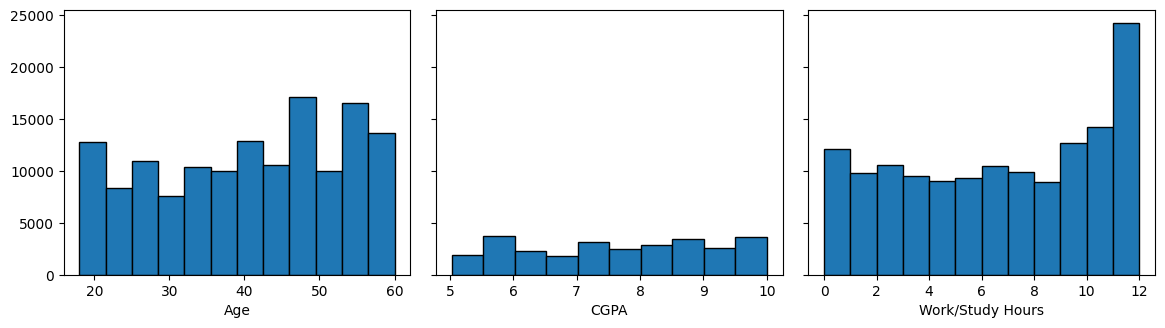

In [119]:
draw_histogram(df_train, hist_cols, hist_bins)

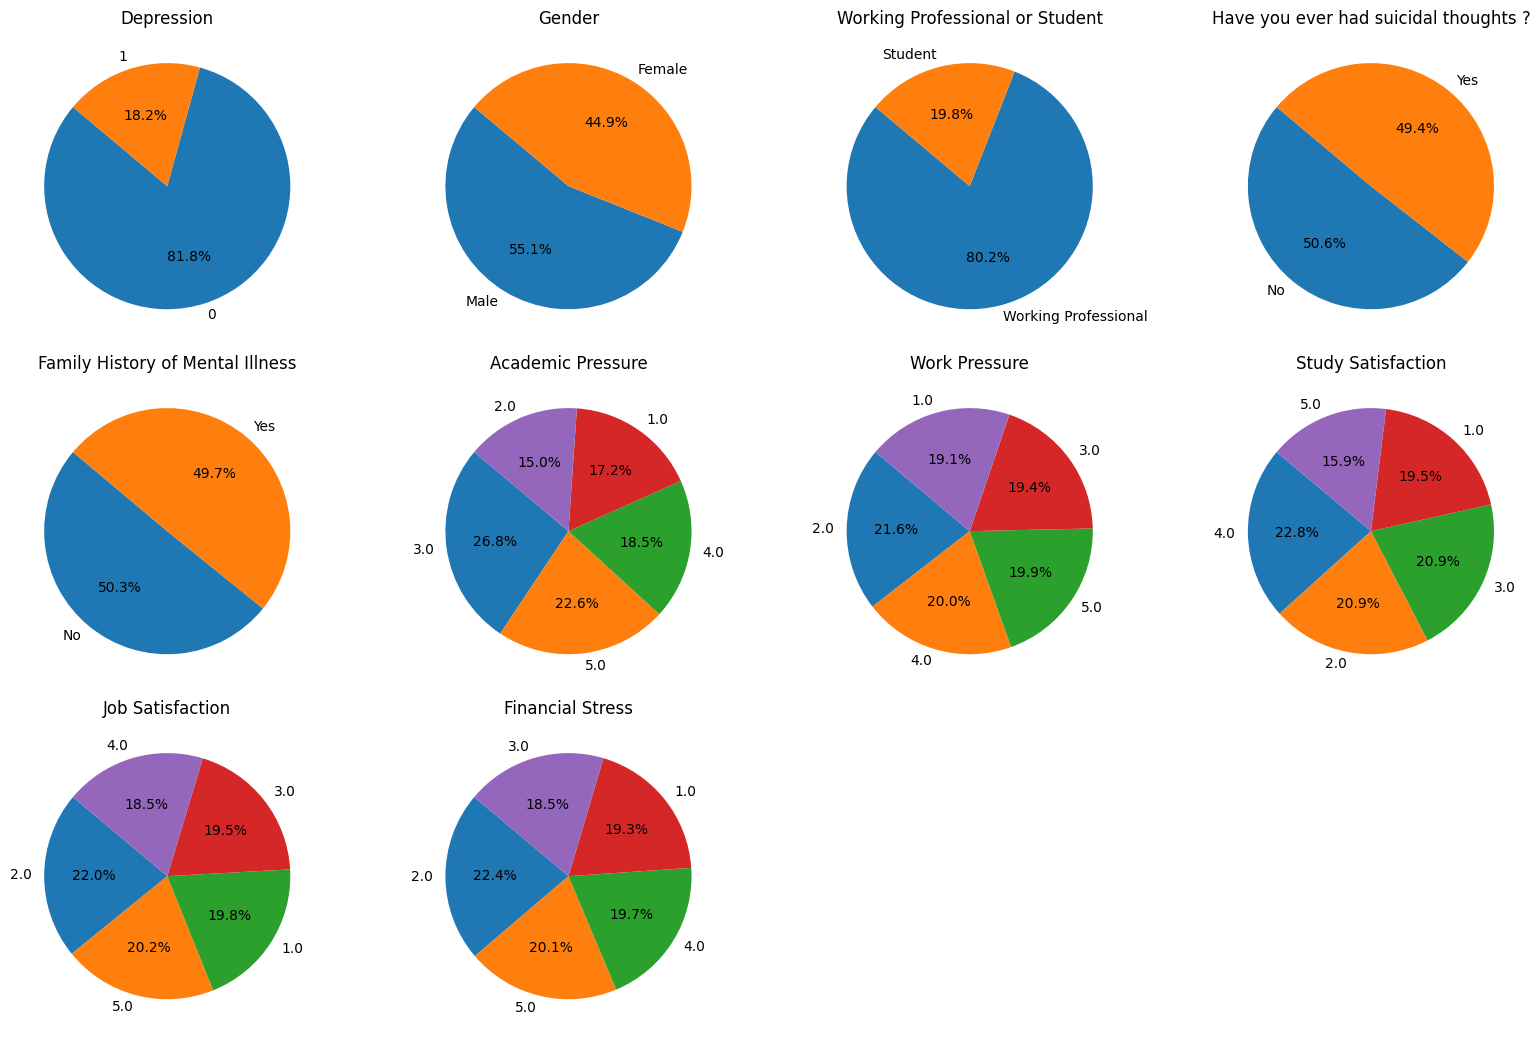

In [126]:
draw_pie_chart(df_train, ['Depression'] + pie_cols)

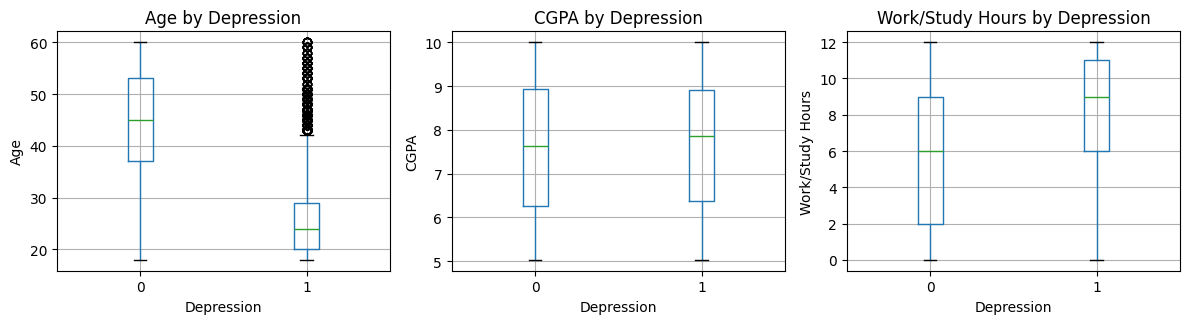

In [121]:
draw_box_plot(df_train, hist_cols, target_col)

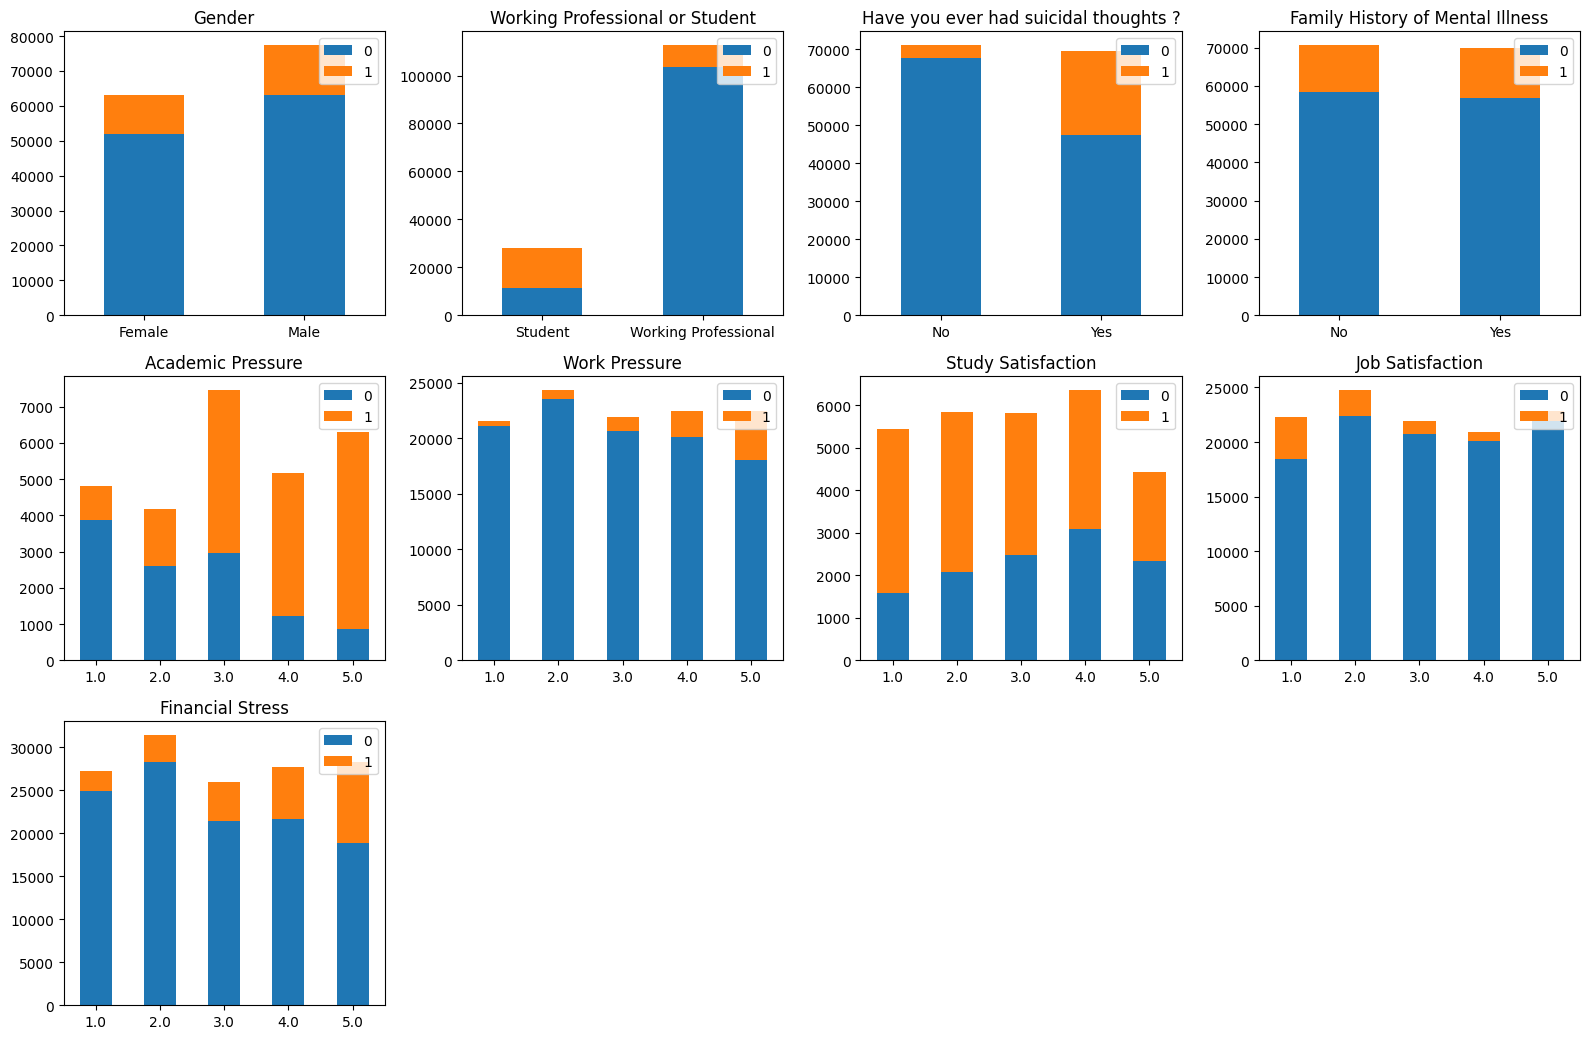

In [124]:
draw_stack_bar(df_train, pie_cols, target_col)

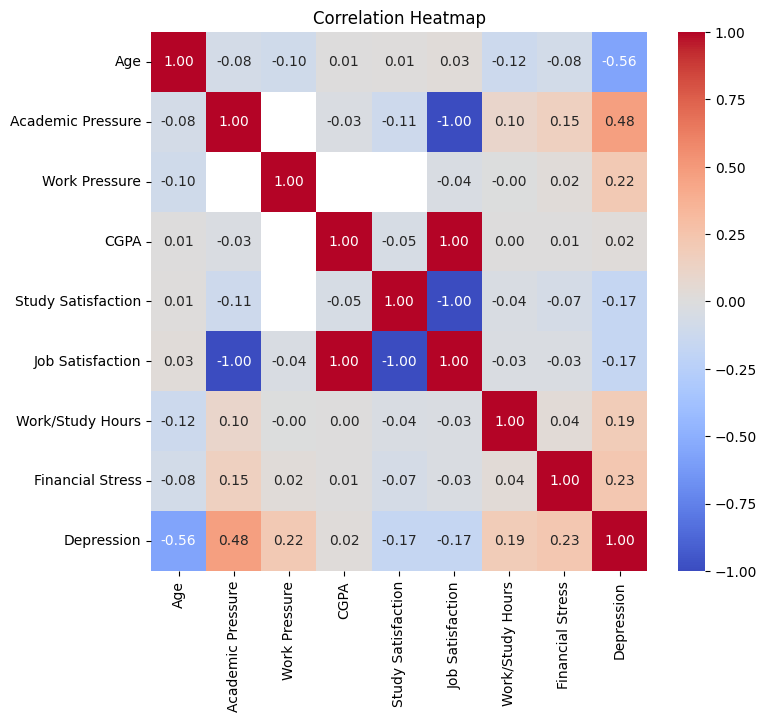

In [140]:
# draw correlation heatmap
corr_data = df_train.drop(columns=['id'])
corr = corr_data.corr(numeric_only=True)
plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()